# 可转债多因子量化交易策略研究

本报告基于可转债日频数据(2018-2024)，对多个量化因子进行分析，
并构建组合策略进行回测评估。

> **数据说明**: 原始数据文件 `cb_data.pq` (182MB) 因体积过大未上传至仓库。
> 本 Notebook 已包含全部运行输出，可直接查看结果，无需重新执行。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

## 1. 数据加载与概览

In [2]:
df = pd.read_parquet('cb_data.pq')
df = df.reset_index()
df['trade_date'] = pd.to_datetime(df['trade_date'])
print(f'数据量: {df.shape[0]} 行, {df.shape[1]} 列')
print(f'时间范围: {df["trade_date"].min().date()} ~ {df["trade_date"].max().date()}')
print(f'转债数量: {df["code"].nunique()}')
print(f'交易日数: {df["trade_date"].nunique()}')

数据量: 559940 行, 80 列
时间范围: 2018-01-02 ~ 2024-12-26
转债数量: 873
交易日数: 1696


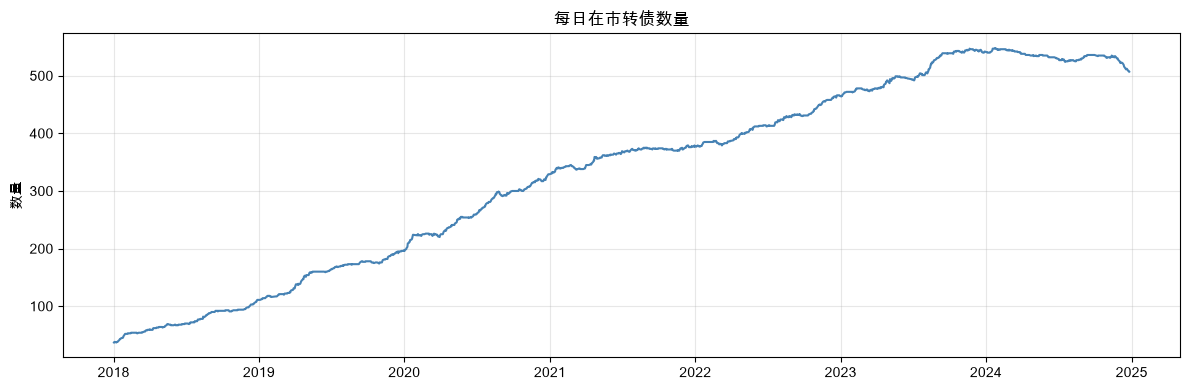

In [3]:
# 每日在市转债数量
daily_count = df.groupby('trade_date')['code'].nunique()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_count.index, daily_count.values, color='steelblue')
ax.set_title('每日在市转债数量')
ax.set_ylabel('数量')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. 因子分析

选取以下因子进行分析:
- **转股溢价率(conv_prem)**: 衡量转债相对正股的溢价程度，越低股性越强
- **双低值(dblow)**: 转债价格+转股溢价率*100，越低攻守兼备
- **到期收益率(ytm)**: 持有至到期的年化收益，越高债底保护越强
- **正股动量(pct_chg_5_stk)**: 正股近5日涨幅，动量效应
- **波动率(volatility)**: 转债价格波动率

In [4]:
# 构造回测所需的矩阵
# 价格矩阵
pricedf = df[['trade_date', 'code', 'close']].set_index(['trade_date', 'code']).unstack()['close']

# 收益率矩阵 (未来一天收益)
day_return = pricedf.pct_change().shift(-1)

print(f'价格矩阵: {pricedf.shape}')
print(f'日期范围: {pricedf.index[0].date()} ~ {pricedf.index[-1].date()}')

价格矩阵: (1696, 873)
日期范围: 2018-01-02 ~ 2024-12-26


In [5]:
# 构造各因子矩阵
def build_factor(col_name):
    return df[['trade_date', 'code', col_name]].set_index(['trade_date', 'code']).unstack()[col_name]

conv_prem = build_factor('conv_prem')
dblow = build_factor('dblow')
ytm = build_factor('ytm')
volatility = build_factor('volatility')
pct_chg_5_stk = build_factor('pct_chg_5_stk')
turnover = build_factor('turnover')

print('因子矩阵构建完成')

因子矩阵构建完成


In [6]:
# 分组回测函数
def group_analysis(factor, forward_return, num=5, title=''):
    cutfactor = factor.rank(axis=1).apply(
        lambda x: pd.qcut(x, num, labels=range(1, num+1), duplicates='drop'), axis=1
    )
    result = pd.DataFrame()
    for group in range(1, 1 + num):
        group_return = forward_return[cutfactor == group].sum(axis=1) / (cutfactor == group).sum(axis=1)
        result[f'G{group}'] = group_return
    result['base'] = forward_return[~factor.isna()].sum(axis=1) / (~factor.isna()).sum(axis=1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    (result + 1).cumprod().plot(ax=axes[0], title=f'{title} - 分组累计净值')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=8)
    
    # 各组年化收益
    annual_ret = result.mean() * 252
    annual_ret.plot(kind='bar', ax=axes[1], color='steelblue', alpha=0.7)
    axes[1].set_title(f'{title} - 各组年化收益')
    axes[1].set_ylabel('年化收益率')
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return result

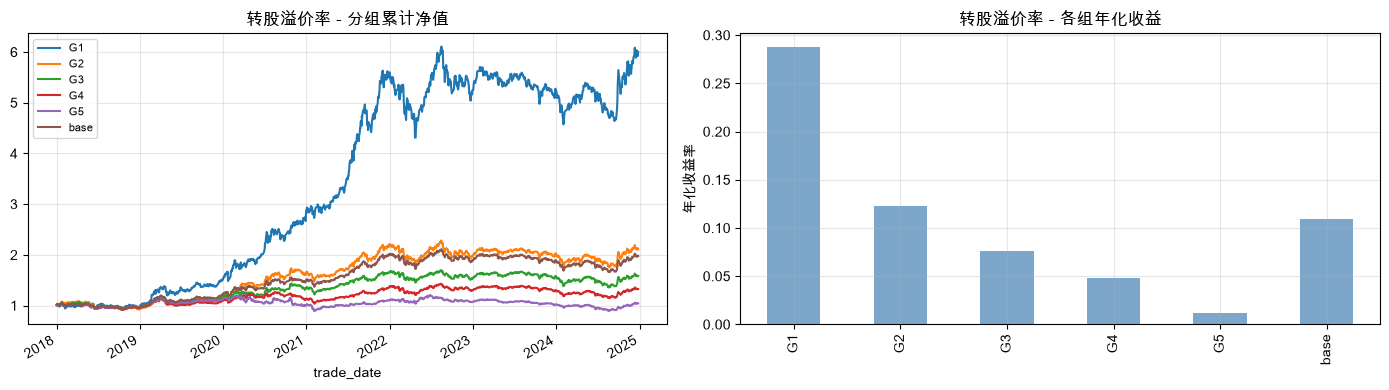

In [7]:
# 转股溢价率因子 (越低越好，所以G1应该表现最好)
result_prem = group_analysis(conv_prem, day_return, title='转股溢价率')

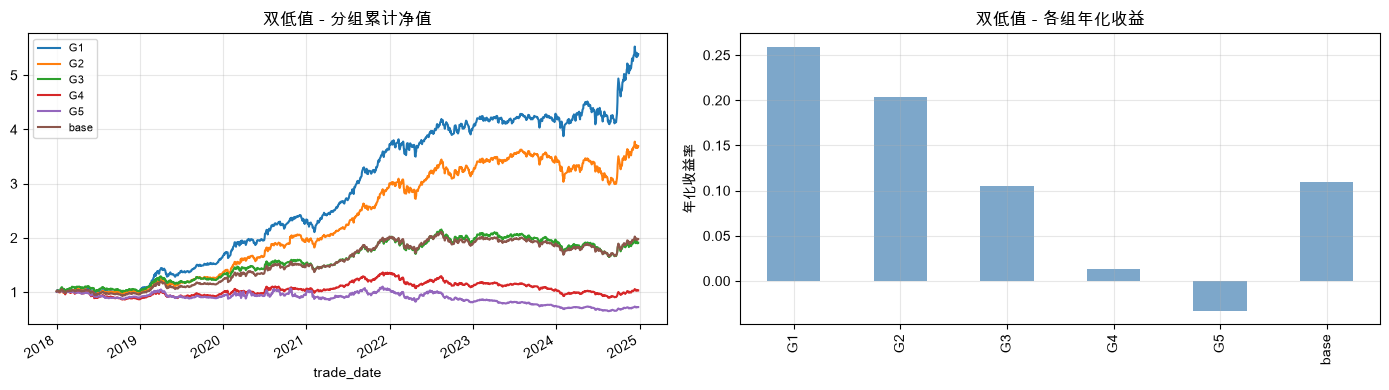

In [8]:
# 双低因子 (越低越好)
result_dblow = group_analysis(dblow, day_return, title='双低值')

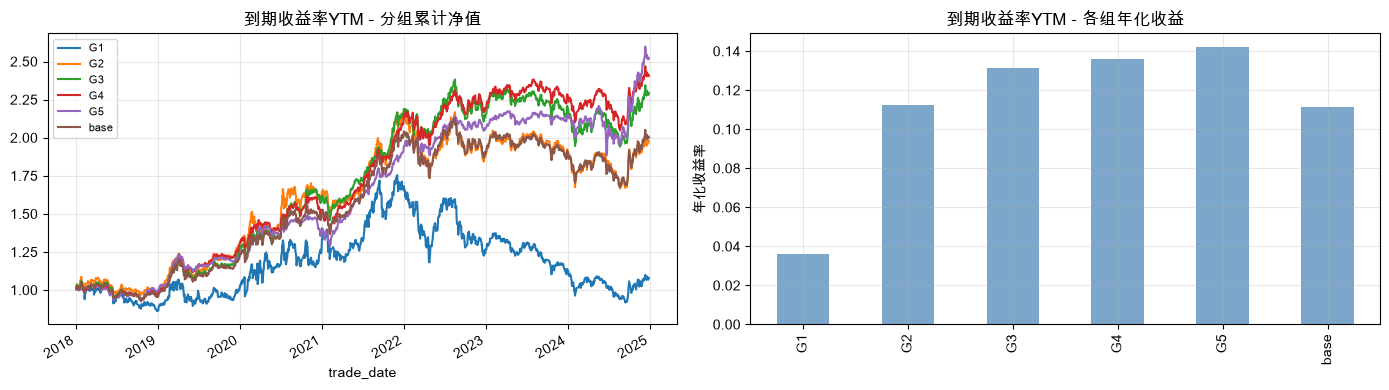

In [9]:
# 到期收益率因子 (越高越好，G5应该表现好)
result_ytm = group_analysis(ytm, day_return, title='到期收益率YTM')

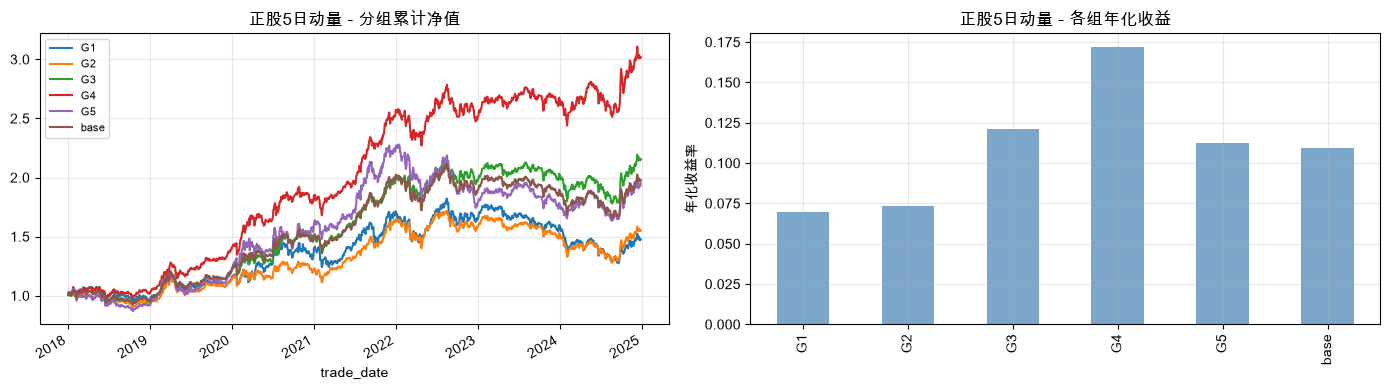

In [10]:
# 正股动量因子 (越高越好)
result_momentum = group_analysis(pct_chg_5_stk, day_return, title='正股5日动量')

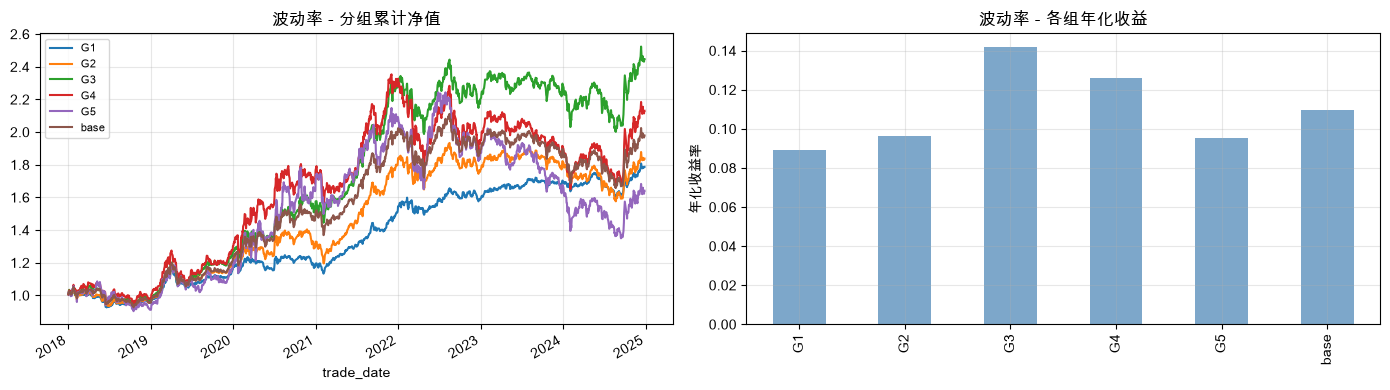

In [11]:
# 波动率因子
result_vol = group_analysis(volatility, day_return, title='波动率')

### 2.1 因子分析小结

| 因子 | 经济逻辑 | 多头方向 |
|------|----------|----------|
| 转股溢价率 | 低溢价=股性强，正股上涨时弹性大 | 做多低溢价(G1) |
| 双低值 | 低价格+低溢价，攻守兼备 | 做多低双低(G1) |
| YTM | 高YTM=低价格，债底保护强 | 做多高YTM(G5) |
| 正股动量 | 动量效应，短期趋势延续 | 做多高动量(G5) |
| 波动率 | 高波动=期权价值高，但风险也大 | 观察分组单调性 |

## 3. 策略构建与回测

基于因子分析结果，构建以下策略:
- **策略1: 双低策略** — 每日选取双低值最低的20只等权持有
- **策略2: 低溢价+动量复合策略** — 先筛选溢价率最低的50%，再按正股动量排序选前20只
- **策略3: 多因子综合** — 对双低、动量、波动率进行排名加权

In [12]:
N = 20  # 持仓数量

def select_top_n(row, n=N, ascending=True):
    row = row.copy()
    valid = row.dropna()
    if len(valid) < n:
        n = len(valid)
    if ascending:
        selected = valid.nsmallest(n).index
    else:
        selected = valid.nlargest(n).index
    row[:] = 0
    row[selected] = 1
    return row

def calc_strategy_stats(pnl, name=''):
    cumret = (pnl + 1).cumprod()
    total_ret = cumret.iloc[-1] - 1
    years = len(pnl) / 252
    annual_ret = (1 + total_ret) ** (1 / years) - 1
    annual_vol = pnl.std() * np.sqrt(252)
    sharpe = annual_ret / annual_vol if annual_vol > 0 else 0
    max_dd = (cumret / cumret.cummax() - 1).min()
    
    print(f'【{name}】')
    print(f'  累计收益: {total_ret:.2%}')
    print(f'  年化收益: {annual_ret:.2%}')
    print(f'  年化波动: {annual_vol:.2%}')
    print(f'  夏普比率: {sharpe:.3f}')
    print(f'  最大回撤: {max_dd:.2%}')
    print()
    return {'name': name, 'annual_ret': annual_ret, 'sharpe': sharpe, 'max_dd': max_dd}

In [13]:
# 策略1: 双低策略
signal_dblow = dblow.apply(select_top_n, axis=1, ascending=True)
pnl_dblow = (signal_dblow * day_return).sum(axis=1) / N
pnl_dblow = pnl_dblow.dropna()

stats_dblow = calc_strategy_stats(pnl_dblow, '双低策略')

【双低策略】
  累计收益: 384.31%
  年化收益: 26.42%
  年化波动: 14.63%
  夏普比率: 1.805
  最大回撤: -20.74%



In [14]:
# 策略2: 低溢价+动量复合
# 先筛选溢价率低的50%，再在里面选动量最高的20只
prem_rank = conv_prem.rank(axis=1, pct=True)
# 只保留溢价率排名前50%的
momentum_filtered = pct_chg_5_stk.copy()
momentum_filtered[prem_rank > 0.5] = np.nan

signal_composite = momentum_filtered.apply(select_top_n, axis=1, ascending=False)
pnl_composite = (signal_composite * day_return).sum(axis=1) / N
pnl_composite = pnl_composite.dropna()

stats_composite = calc_strategy_stats(pnl_composite, '低溢价+动量')

【低溢价+动量】
  累计收益: 265.23%
  年化收益: 21.22%
  年化波动: 22.83%
  夏普比率: 0.930
  最大回撤: -40.05%



In [15]:
# 策略3: 多因子综合打分
# 双低排名(越低越好) + 动量排名(越高越好) + 换手率排名(越高越好，流动性好)
rank_dblow = dblow.rank(axis=1, ascending=True)  # 低双低排前面
rank_momentum = pct_chg_5_stk.rank(axis=1, ascending=False)  # 高动量排前面
rank_turnover = turnover.rank(axis=1, ascending=False)  # 高换手排前面

# 综合得分 (排名越小越好)
composite_score = rank_dblow * 0.5 + rank_momentum * 0.3 + rank_turnover * 0.2

signal_multi = composite_score.apply(select_top_n, axis=1, ascending=True)
pnl_multi = (signal_multi * day_return).sum(axis=1) / N
pnl_multi = pnl_multi.dropna()

stats_multi = calc_strategy_stats(pnl_multi, '多因子综合')

【多因子综合】
  累计收益: 1008.76%
  年化收益: 42.97%
  年化波动: 16.98%
  夏普比率: 2.531
  最大回撤: -14.64%



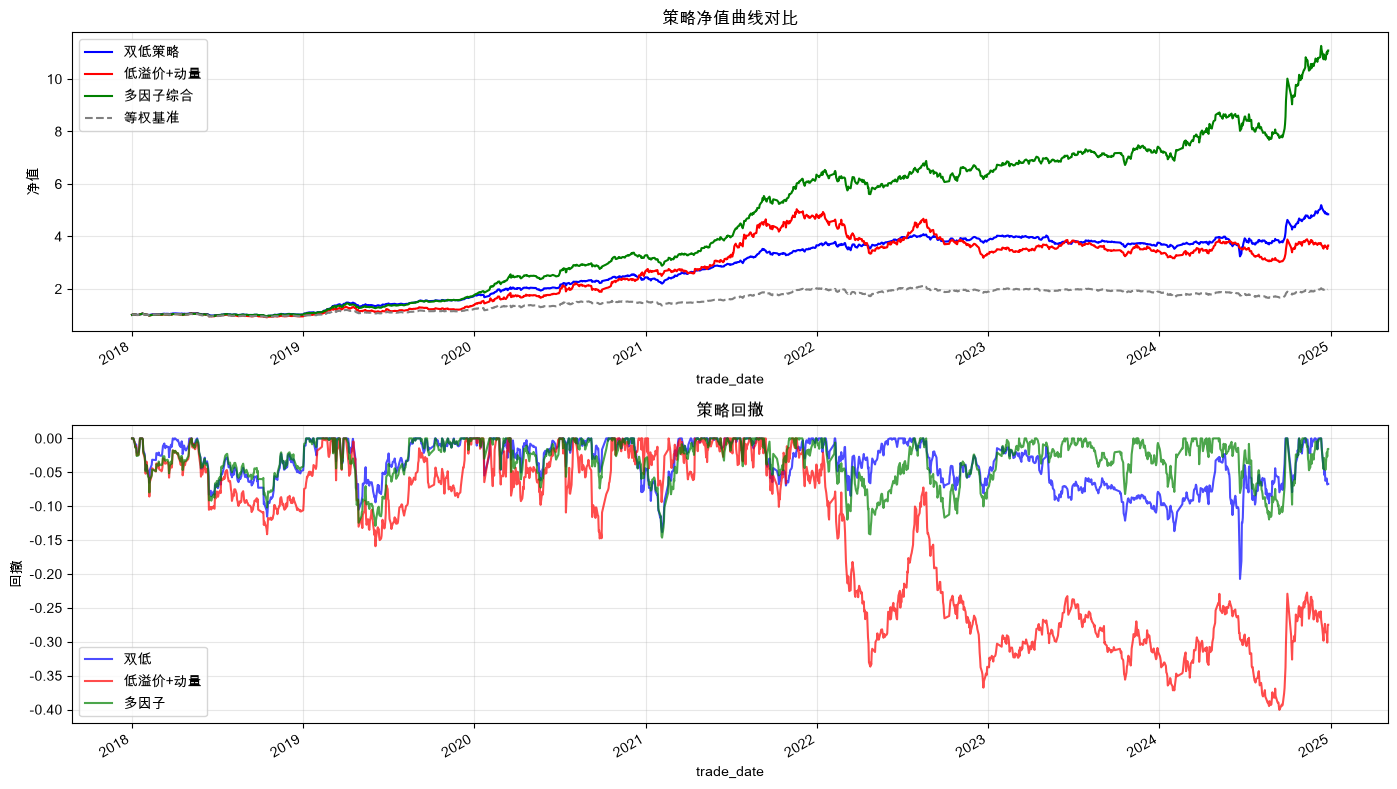

In [16]:
# 策略对比
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 净值曲线
ax = axes[0]
(pnl_dblow + 1).cumprod().plot(ax=ax, label='双低策略', color='blue')
(pnl_composite + 1).cumprod().plot(ax=ax, label='低溢价+动量', color='red')
(pnl_multi + 1).cumprod().plot(ax=ax, label='多因子综合', color='green')

# 等权基准
base_pnl = day_return.mean(axis=1).dropna()
(base_pnl + 1).cumprod().plot(ax=ax, label='等权基准', color='gray', linestyle='--')

ax.set_title('策略净值曲线对比')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylabel('净值')

# 回撤曲线
ax = axes[1]
for pnl, name, color in [(pnl_dblow, '双低', 'blue'), 
                          (pnl_composite, '低溢价+动量', 'red'),
                          (pnl_multi, '多因子', 'green')]:
    cumret = (pnl + 1).cumprod()
    dd = cumret / cumret.cummax() - 1
    dd.plot(ax=ax, label=name, color=color, alpha=0.7)

ax.set_title('策略回撤')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylabel('回撤')

plt.tight_layout()
plt.show()

## 4. 策略评估汇总

In [17]:
# 汇总表
results = []
for pnl, name in [(pnl_dblow, '双低策略'), (pnl_composite, '低溢价+动量'), 
                   (pnl_multi, '多因子综合'), (base_pnl, '等权基准')]:
    cumret = (pnl + 1).cumprod()
    total = cumret.iloc[-1] - 1
    yrs = len(pnl) / 252
    ann_ret = (1 + total) ** (1/yrs) - 1
    ann_vol = pnl.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    max_dd = (cumret / cumret.cummax() - 1).min()
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0
    results.append({
        '策略': name,
        '累计收益': f'{total:.2%}',
        '年化收益': f'{ann_ret:.2%}',
        '年化波动': f'{ann_vol:.2%}',
        '夏普比率': f'{sharpe:.3f}',
        '最大回撤': f'{max_dd:.2%}',
        'Calmar': f'{calmar:.3f}'
    })

eval_df = pd.DataFrame(results)
eval_df

,策略,累计收益,年化收益,年化波动,夏普比率,最大回撤,Calmar
0,双低策略,384.31%,26.42%,14.63%,1.805,-20.74%,1.274
1,低溢价+动量,265.23%,21.22%,22.83%,0.930,-40.05%,0.530
2,多因子综合,1008.76%,42.97%,16.98%,2.531,-14.64%,2.934
3,等权基准,97.84%,10.68%,12.77%,0.836,-21.48%,0.497


### 4.1 分年度表现

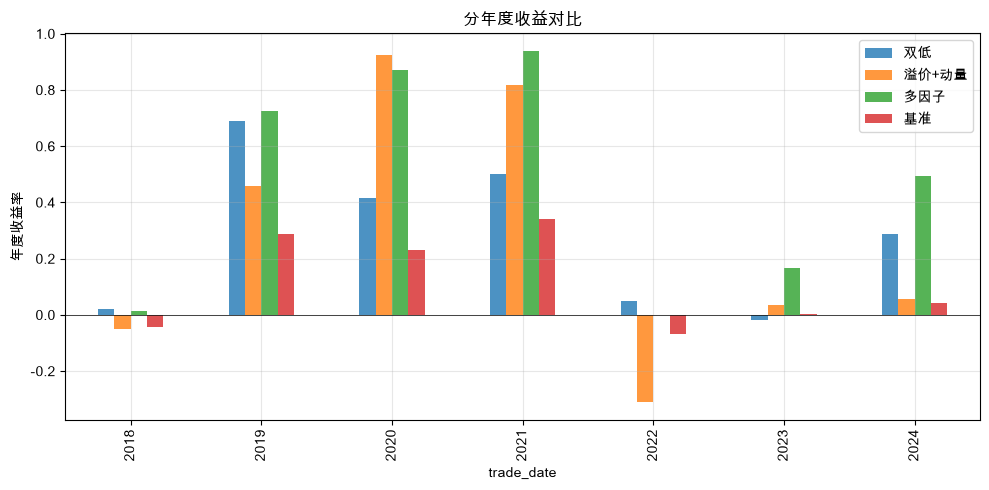

                双低    溢价+动量     多因子      基准
trade_date                                 
2018         1.99%   -5.02%   1.51%  -4.48%
2019        69.12%   45.67%  72.44%  28.63%
2020        41.55%   92.57%  87.24%  22.94%
2021        49.98%   81.76%  93.91%  33.94%
2022         4.76%  -31.04%   0.06%  -6.65%
2023        -1.89%    3.39%  16.73%   0.41%
2024        28.68%    5.77%  49.37%   4.32%


In [18]:
# 分年度收益
yearly_results = {}
for pnl, name in [(pnl_dblow, '双低'), (pnl_composite, '溢价+动量'), 
                   (pnl_multi, '多因子'), (base_pnl, '基准')]:
    yearly = pnl.groupby(pnl.index.year).apply(lambda x: (1+x).prod() - 1)
    yearly_results[name] = yearly

yearly_df = pd.DataFrame(yearly_results)

fig, ax = plt.subplots(figsize=(10, 5))
yearly_df.plot(kind='bar', ax=ax, alpha=0.8)
ax.set_title('分年度收益对比')
ax.set_ylabel('年度收益率')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print(yearly_df.map(lambda x: f'{x:.2%}'))